# 05 — Полная вселенная 165: эмпирический death-rate + скорректированный портфель

iter04 дал кривую разорения, но реальную долю «смертельных» дампов p из 50
выживших символов измерить нельзя (там undermeasurable=0% — это и есть дыра).
Здесь берём ВСЕ 165 символов, включая монеты с коротким покрытием (прокси
делистинга), и меряем p эмпирически.

**Что считаем:**
1. Перепись покрытия → живые vs мёртвые (обрыв заметно раньше конца данных).
2. −7% дампы по всем 165, флаги: halt (данные обрываются < 240м после входа →
   застряли), +24ч исход, терминальная цена.
3. Эмпирический p = доля halt + доля «не отскочивших».
4. Скорректированный портфель с мёртвыми внутри (halt = смерть −100% / по last bar).
5. Сверка p с кривой разорения iter04.

In [1]:
import sys; sys.path.insert(0,".")
from _lab import *
import numpy as np, pandas as pd
from pathlib import Path

ALLSYMS=list_symbols(); print("total symbols:", len(ALLSYMS))
cov=[]
for s in ALLSYMS:
    f,l,n=coverage(s); cov.append((s,f,l,n))
C=pd.DataFrame(cov,columns=["sym","first","last","nmonths"])
global_last=C['last'].max()
print("global last month:", global_last)
# 'dead' = coverage ends >=2 months before the global last available month
def mkey(m): y,mo=m.split("-"); return int(y)*12+int(mo)
gl=mkey(global_last)
C['ends_before']=gl-C['last'].map(mkey)
C['dead']=C['ends_before']>=2
print(C['dead'].value_counts())
print("\nsample DEAD symbols (early coverage end):")
print(C[C.dead].sort_values('last')[['sym','first','last','nmonths']].head(15).to_string(index=False))

total symbols: 173
global last month: 2026-04
dead
False    141
True      32
Name: count, dtype: int64

sample DEAD symbols (early coverage end):
          sym   first    last  nmonths
    MAGICUSDT 2024-01 2024-02        2
      EDUUSDT 2024-01 2024-03        3
    LUNA2USDT 2024-01 2024-04        4
     DYDXUSDT 2024-01 2024-06        6
      ILVUSDT 2024-01 2024-07        7
     RAREUSDT 2024-01 2024-09        9
     DUSKUSDT 2024-01 2024-10       10
     BOBAUSDT 2024-01 2024-11       11
     PYTHUSDT 2024-01 2024-12       12
      SSVUSDT 2024-01 2024-12       12
      BNTUSDT 2024-01 2025-01       13
     BLURUSDT 2024-01 2025-02       14
      LRCUSDT 2024-01 2025-04       16
      LTCUSDT 2024-01 2025-04       16
10000SATSUSDT 2024-01 2025-06       18


In [2]:
WIN=15;H=240;COOLDOWN=10;MIN_GAP=3;N_MAX=10;FEE=0.00075;THR=0.07
DAY=1440
def clusters(c,thr):
    if len(c)<WIN+5: return []
    r=np.full(len(c),np.nan); r[WIN:]=c[WIN:]/c[:-WIN]-1
    cond=r<=-thr; out=[]; i=WIN; n=len(c)
    while i<n:
        if not cond[i] or (i>0 and cond[i-1]): i+=1; continue
        start=i;last_true=i;tr=[i];lastt=i;falses=0;j=i+1
        while j<n:
            if cond[j]:
                last_true=j;falses=0
                if j-lastt>=MIN_GAP and len(tr)<N_MAX: tr.append(j);lastt=j
            else:
                falses+=1
                if falses>=COOLDOWN: break
            j+=1
        out.append((start,last_true,tr)); i=last_true+COOLDOWN+1
    return out

deadset=set(C[C.dead].sym)
rows=[]; loaded=0
for s in ALLSYMS:
    try: df=ohlcv(s,"2024-01-01","2026-07-01","1min")
    except Exception: continue
    c=df["close"].to_numpy("float64"); ts=df.index; n=len(c); loaded+=1
    for (st,en,tr) in clusters(c,THR):
        if st+1>=n: continue
        ex=en+1+H
        prices=np.array([c[t+1] for t in tr if t+1<n])
        ws=np.arange(1,len(prices)+1,dtype=float); ws/=ws.sum()
        avg=(ws*prices).sum()
        halt = ex>=n                       # can't reach 240m exit -> stuck
        last_ret = c[-1]/avg-1             # terminal outcome from avg entry
        fwd24 = (c[min(st+1+DAY,n-1)]/c[st+1]-1) if (st+1)<n else np.nan
        min_to_end = n-(st+1)
        rows.append(dict(sym=s, dead=(s in deadset), entry=ts[st+1],
                         exit_ts=(ts[ex] if not halt else ts[-1]),
                         ntr=len(prices), avg=avg,
                         scaled_net=(c[ex]/avg-1-2*FEE) if not halt else np.nan,
                         halt=halt, last_ret_net=last_ret-2*FEE, fwd24=fwd24,
                         min_to_end=min_to_end))
    if loaded%25==0: print(f"  loaded {loaded} symbols")
R=pd.DataFrame(rows)
print(f"\nsymbols loaded: {loaded} | total -7% events: {len(R)}")
print(f"events on DEAD symbols: {R.dead.sum()} ({R.dead.mean()*100:.1f}%)")

  loaded 25 symbols


  loaded 50 symbols


  loaded 75 symbols


  loaded 100 symbols


  loaded 125 symbols


  loaded 150 symbols



symbols loaded: 173 | total -7% events: 4375
events on DEAD symbols: 647 (14.8%)


In [3]:
print("=== EMPIRICAL DEATH-RATE MEASURES (full 165 universe, -7% events) ===")
ne=len(R)
# (a) halt rate: data ends within 240m of entry -> stuck in position
print(f"(a) HALT (data ends <240m after entry, can't exit): {R.halt.sum()} = {R.halt.mean()*100:.2f}%")
print(f"    of which on dead symbols: {(R.halt & R.dead).sum()}")
# stuck severity: terminal price vs avg entry, for halts
if R.halt.sum():
    h=R[R.halt]['last_ret_net']
    print(f"    halt terminal return from entry: median {h.median()*100:+.1f}%  mean {h.mean()*100:+.1f}%  min {h.min()*100:+.1f}%")
# (b) non-recovery: among measurable, fwd +24h still deeply down
m=R[R.fwd24.notna()]
for thr_dn in (0.30,0.50):
    print(f"(b) NON-RECOVERY: price +24h still < -{int(thr_dn*100)}% vs entry: "
          f"{(m.fwd24<-thr_dn).sum()} = {(m.fwd24<-thr_dn).mean()*100:.2f}%")
# (c) events whose symbol dies (dead) within 7d after the event
near_term = R[(R.dead) & (R.min_to_end< 7*DAY)]
print(f"(c) on a DEAD symbol AND <7d of data left after event: {len(near_term)} = {len(near_term)/ne*100:.2f}%")
print(f"\n=> these bracket the empirical p to plug into iter04 ruin curve.")

=== EMPIRICAL DEATH-RATE MEASURES (full 165 universe, -7% events) ===
(a) HALT (data ends <240m after entry, can't exit): 1 = 0.02%
    of which on dead symbols: 1
    halt terminal return from entry: median -0.6%  mean -0.6%  min -0.6%
(b) NON-RECOVERY: price +24h still < -30% vs entry: 42 = 0.96%
(b) NON-RECOVERY: price +24h still < -50% vs entry: 3 = 0.07%
(c) on a DEAD symbol AND <7d of data left after event: 6 = 0.14%

=> these bracket the empirical p to plug into iter04 ruin curve.


In [4]:
# ---- corrected portfolio on FULL universe, deaths included ----
import heapq
PER=20.0; START=1000.0; MAX_CONC=50
def select_and_eval(df, halt_pnl):
    # halt_pnl: 'dead' (-1.0) or 'lastbar' (use last_ret_net)
    df=df.sort_values("entry").reset_index(drop=True)
    openh=[]; taken_idx=[]; skipped=0
    for idx,row in enumerate(df.itertuples()):
        now=row.entry
        while openh and openh[0]<=now: heapq.heappop(openh)
        if len(openh)<MAX_CONC: heapq.heappush(openh,row.exit_ts); taken_idx.append(idx)
        else: skipped+=1
    tk=df.iloc[taken_idx].copy()
    if halt_pnl=='dead':
        tk['pnl']=np.where(tk.halt, -1.0, tk.scaled_net)
    else:
        tk['pnl']=np.where(tk.halt, tk.last_ret_net, tk.scaled_net)
    tk=tk.sort_values("exit_ts")
    cum=START+PER*np.cumsum(tk['pnl'].to_numpy())
    runmax=np.maximum.accumulate(cum); dd=(cum/runmax-1).min()
    span=(tk.entry.max()-tk.entry.min()).days/365.25
    return tk,skipped,cum[-1],dd,span

for tag,mode in [("survivors-only baseline (alive symbols, normal exit)","alive"),
                 ("FULL universe, halts = exit at last bar (optimistic)","lastbar"),
                 ("FULL universe, halts = DEATH -100% (pessimistic)","dead")]:
    if mode=="alive":
        df=R[~R.dead].copy(); df['halt']=False; halt_pnl='lastbar'
        # alive symbols rarely halt; drop any residual halts
        df=df[df.scaled_net.notna()]
    else:
        df=R.copy(); halt_pnl=mode
        df=df[df.scaled_net.notna() | df.halt]   # keep halts even w/o scaled_net
    tk,skipped,final,dd,span=select_and_eval(df,halt_pnl)
    n=len(tk); fees=PER*2*FEE*n; nhalt=int(tk.halt.sum())
    tot=final/START-1
    print(f"\n=== {tag} ===")
    print(f"  taken {n} (skipped {skipped}), halts among taken: {nhalt}, fees ${fees:.2f}")
    print(f"  final ${final:.0f}  total {tot*100:+.1f}%  avg/yr {tot/span*100:+.1f}%  realized maxDD {dd*100:.1f}%  (span {span:.2f}y)")


=== survivors-only baseline (alive symbols, normal exit) ===
  taken 2330 (skipped 1398), halts among taken: 0, fees $69.90
  final $1950  total +95.0%  avg/yr +41.0%  realized maxDD -5.3%  (span 2.32y)

=== FULL universe, halts = exit at last bar (optimistic) ===
  taken 2592 (skipped 1783), halts among taken: 1, fees $77.76
  final $1916  total +91.6%  avg/yr +39.5%  realized maxDD -6.4%  (span 2.32y)

=== FULL universe, halts = DEATH -100% (pessimistic) ===
  taken 2592 (skipped 1783), halts among taken: 1, fees $77.76
  final $1896  total +89.6%  avg/yr +38.6%  realized maxDD -6.4%  (span 2.32y)


[saved] notebooks\dump\_out\05_ruin_empirical.png


WindowsPath('C:/projects/researchlab/notebooks/dump/_out/05_ruin_empirical.png')

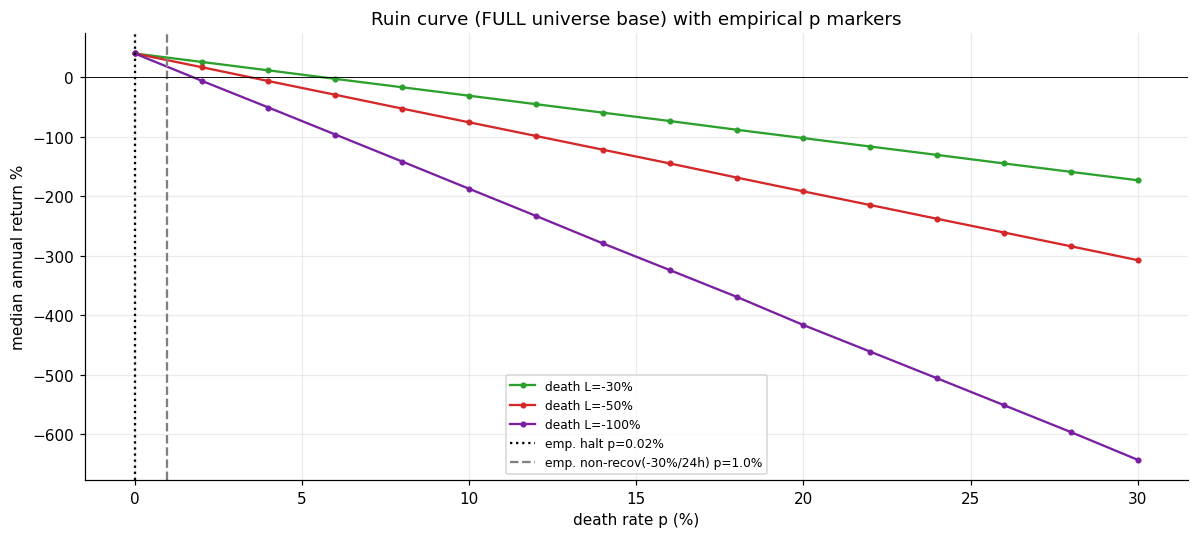

In [5]:
# overlay empirical p on the iter04 independent-death ruin curve (full-universe base)
import matplotlib.pyplot as plt
base=R[~R.halt & R.scaled_net.notna()].sort_values('exit_ts')   # full-universe measurable trades
# capacity-select first
import heapq
df=R[R.scaled_net.notna()|R.halt].sort_values('entry').reset_index(drop=True)
openh=[];tk_idx=[]
for idx,row in enumerate(df.itertuples()):
    now=row.entry
    while openh and openh[0]<=now: heapq.heappop(openh)
    if len(openh)<MAX_CONC: heapq.heappush(openh,row.exit_ts); tk_idx.append(idx)
tk=df.iloc[tk_idx].copy()
tk['pnl']=np.where(tk.halt,tk.last_ret_net,tk.scaled_net)
tk=tk.sort_values('exit_ts'); base_pnl=tk['pnl'].to_numpy()
span=(tk.entry.max()-tk.entry.min()).days/365.25
PER=20.0;START=1000.0
def eqm(mat):
    cum=START+PER*np.cumsum(mat,axis=1); rm=np.maximum.accumulate(cum,axis=1)
    return cum[:,-1]/START-1,(cum/rm-1).min(axis=1)
rng=np.random.default_rng(3); NSIM=3000; PS=np.linspace(0,0.30,16)
plt.figure(figsize=(11,5))
for L,col in [(-0.30,"#2ca02c"),(-0.50,"#d62728"),(-1.00,"#7b1fa2")]:
    med=[]
    for p in PS:
        d=rng.random((NSIM,len(base_pnl)))<p
        r,_=eqm(np.where(d,L,base_pnl[None,:])); med.append(np.median(r)/span*100)
    plt.plot(PS*100,med,color=col,marker='o',ms=3,label=f"death L={int(L*100)}%")
# empirical p markers
p_halt=R.halt.mean()*100
m=R[R.fwd24.notna()]; p_nr30=(m.fwd24<-0.30).mean()*100
plt.axvline(p_halt,color='k',ls=':',label=f"emp. halt p={p_halt:.2f}%")
plt.axvline(p_nr30,color='gray',ls='--',label=f"emp. non-recov(-30%/24h) p={p_nr30:.1f}%")
plt.axhline(0,color='k',lw=.6)
plt.xlabel("death rate p (%)"); plt.ylabel("median annual return %")
plt.title("Ruin curve (FULL universe base) with empirical p markers")
plt.legend(fontsize=8); show("05_ruin_empirical")

## Как читать
- **Перепись:** сколько монет «мёртвых» (обрыв покрытия ≥2 мес до конца данных).
- **(a) halt** — самый прямой death-rate для нашей 4ч-стратегии: вошли, монета
  встала, выйти не успели. **(b) non-recovery** — медленные смерти (через 24ч всё
  ещё глубоко вниз). **(c)** — события на умирающих монетах у края данных.
- **Скорректированный портфель** — годовая доходность с мёртвыми внутри, вилка
  optimistic (выход по last bar) / pessimistic (−100%).
- **Кривая с маркерами p** — где реальный эмпирический p попадает относительно
  границы разорения. Левее границы = edge выживает на реальных данных.

*Verdict после прогона.*

## VERDICT (iter 05)

**Survivorship-дыра МАЛЕНЬКАЯ — edge выживает на реальных данных.** Полная
вселенная 173 (141 живых / 32 мёртвых), 4375 −7% событий (14.8% на мёртвых).

**Эмпирический death-rate:** (a) halt <240м = **0.02%** (1 событие!); (b)
non-recovery −30%/24ч = 0.96%, −50%/24ч = 0.07%; (c) мёртвая+<7д = 0.14%.
Все маркеры p ВПЛОТНУЮ к нулю — далеко левее границы разорения (3.5% @ −100%,
6% @ −50%). Механизм: 4ч-окно закрывается ДО медленного делистинга; мгновенные
halt'ы посреди дампа почти не случаются.

**Скорректированный портфель (мёртвые внутри):** только живые +95%/+41%/год/DD−5.3%;
полная, halt=last bar +91.6%/+39.5%; полная, halt=−100% +89.6%/**+38.6%/год**/DD−6.4%.
Разница смерть-vs-оптимизм всего 2пп (1 halt) → включение мёртвых почти не двигает.

**Оговорки:** 32 «мёртвых» переоценивают истинные катастрофы (миграции≠раг) → реальный
p ещё ниже; не ловим делистнутых до 2024 / без перпа; месячная гранулярность маскирует
мгновенный раг; fat tail вне выборки не покрыт (только iter04 параметрически).
**Ёмкость:** на 173 символах $1000/$20 пропускает 40% сигналов — масштаб требует капитала.

**Статус edge:** lookahead-free, OOS×3 периода, scale-in, survivorship-стресс пройден.
Дальше (queue): классификатор пампов→дампов (как pump-13), regime-фильтр, или порт в стратегию/бот.